In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"parthshrivastava22","key":"de1a0085e2e7cf84db3345347c60ccc8"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d moltean/fruits

Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 5.45G/5.45G [01:18<00:00, 74.9MB/s]



In [ ]:
!unzip -q fruits.zip

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'fruits-360_original-size', 'fruits.zip', 'fruits-360_meta', 'fruits-360_multi', 'fruits-360_3-body-problem', 'fruits-360_100x100', 'kaggle.json', 'sample_data']


In [ ]:
print(os.listdir("/content/fruits-360_original-size/fruits-360-original-size"))

['Training', 'Test', 'README.md', 'Validation', 'Papers', 'LICENSE']


In [ ]:
import tensorflow as tf
import numpy as np

batch_size = 32
img_size = (64, 64)

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/fruits-360_original-size/fruits-360-original-size/Training",
    image_size=img_size,
    batch_size=batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/fruits-360_original-size/fruits-360-original-size/Validation",
    image_size=img_size,
    batch_size=batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/fruits-360_original-size/fruits-360-original-size/Test",
    image_size=img_size,
    batch_size=batch_size
)

original_classes = train_ds.class_names

Found 49912 files belonging to 141 classes.
Found 24963 files belonging to 141 classes.
Found 24810 files belonging to 141 classes.


In [ ]:
import re

TARGET_CLASSES = set([
    'Apple', 'Avocado', 'Banana', 'Cherry',
    'Cocos', 'Kiwi', 'Lemon', 'Mango', 'Orange'
])

def get_base_fruit(class_name):
    s = class_name.lower().replace('_', ' ')

    rules = [
        ('apple', 'Apple'), ('avocado', 'Avocado'), ('banana', 'Banana'),
        ('cherry', 'Cherry'), ('cocos', 'Cocos'), ('kiwi', 'Kiwi'),
        ('lemon', 'Lemon'), ('mango', 'Mango'), ('orange', 'Orange')
    ]

    for key, value in rules:
        if key in s:
            return value
    return None

In [ ]:
def map_and_filter(image, label):
    original_label = original_classes[label.numpy()]
    new_label_name = get_base_fruit(original_label)

    if new_label_name is None:
        return None

    new_label = new_class_names.index(new_label_name)
    return image, new_label

In [ ]:
valid_indices = []
mapping_array = []

for i, name in enumerate(original_classes):
    mapped = get_base_fruit(name)
    if mapped is not None:
        valid_indices.append(i)
        mapping_array.append(mapped)

In [ ]:
new_class_names = sorted(list(set(mapping_array)))
num_classes = len(new_class_names)
class_to_idx = {name: i for i, name in enumerate(new_class_names)}

mapping_array_final = []

for name in original_classes:
    mapped = get_base_fruit(name)
    if mapped is None:
        mapping_array_final.append(-1)
    else:
        mapping_array_final.append(class_to_idx[mapped])

mapping_tensor = tf.constant(mapping_array_final)

In [ ]:
from collections import Counter

counts = Counter()

for _, labels in train_ds.unbatch().take(10000):
    counts[int(labels.numpy())] += 1

print(counts)

Counter({59: 148, 38: 135, 55: 132, 77: 129, 92: 126, 105: 118, 90: 113, 104: 111, 100: 110, 32: 109, 73: 107, 80: 105, 117: 104, 21: 104, 54: 103, 74: 103, 70: 102, 91: 102, 103: 101, 4: 101, 79: 100, 56: 100, 118: 99, 40: 99, 39: 99, 43: 99, 7: 98, 89: 98, 50: 97, 84: 97, 86: 96, 96: 96, 20: 95, 11: 95, 106: 94, 8: 94, 33: 94, 93: 93, 115: 91, 102: 91, 30: 90, 41: 90, 6: 90, 83: 90, 22: 90, 94: 90, 71: 90, 16: 90, 116: 89, 1: 89, 76: 89, 42: 88, 15: 88, 119: 86, 78: 85, 114: 85, 45: 84, 9: 83, 113: 83, 57: 83, 101: 81, 19: 81, 63: 76, 17: 76, 88: 75, 134: 71, 82: 70, 28: 70, 133: 70, 47: 70, 61: 69, 95: 66, 135: 65, 36: 65, 62: 65, 98: 64, 5: 64, 124: 63, 128: 63, 137: 62, 111: 62, 109: 61, 58: 61, 99: 61, 64: 61, 52: 61, 107: 61, 48: 60, 14: 60, 75: 59, 129: 59, 130: 59, 85: 58, 35: 58, 131: 58, 108: 58, 26: 58, 12: 57, 136: 56, 3: 56, 126: 55, 44: 55, 132: 54, 60: 54, 13: 54, 127: 51, 2: 49, 10: 47, 18: 46, 123: 45, 121: 44, 72: 44, 29: 44, 122: 38, 69: 38, 66: 38, 67: 38, 24: 37, 

In [ ]:
def map_labels(image, label):
    new_label = tf.gather(mapping_tensor, label)
    return image, new_label

train_ds = train_ds.map(map_labels)
train_ds = train_ds.unbatch()
train_ds = train_ds.filter(lambda x, y: tf.not_equal(y, -1))
train_ds = train_ds.batch(batch_size)

val_ds = val_ds.map(map_labels)
val_ds = val_ds.unbatch()
val_ds = val_ds.filter(lambda x, y: tf.not_equal(y, -1))
val_ds = val_ds.batch(batch_size)

test_ds = test_ds.map(map_labels)
test_ds = test_ds.unbatch()
test_ds = test_ds.filter(lambda x, y: tf.not_equal(y, -1))
test_ds = test_ds.batch(batch_size)

In [ ]:
import keras
from keras import regularizers

model = keras.Sequential([
    keras.layers.Input(shape=(64, 64, 3)),
    keras.layers.Rescaling(1./255),

    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(),

    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(9, activation='softmax')
])

In [ ]:
optimizer = keras.optimizers.Adam(learning_rate=0.0005)

model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from sklearn.utils import class_weight
import numpy as np

total = sum(counts.values())
num_classes = len(new_class_names)

class_weights_dict = {i: total / (num_classes * counts[i]) for i in counts}

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.00001
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath='fruit_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [ ]:
train_ds = train_ds.repeat()
steps_per_epoch = 300

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    steps_per_epoch=steps_per_epoch,
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.8289 - loss: 0.6742
Epoch 1: val_accuracy improved from None to 0.25263, saving model to fruit_model.keras

Epoch 1: finished saving model to fruit_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 164s 535ms/step - accuracy: 0.9121 - loss: 0.2945 - val_accuracy: 0.2526 - val_loss: 5.3880 - learning_rate: 5.0000e-04
Epoch 2/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.9709 - loss: 0.0799
Epoch 2: val_accuracy improved from 0.25263 to 0.90073, saving model to fruit_model.keras

Epoch 2: finished saving model to fruit_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 157s 525ms/step - accuracy: 0.9767 - loss: 0.0680 - val_accuracy: 0.9007 - val_loss: 1.7463 - learning_rate: 5.0000e-04
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9812 - loss: 0.0543
Epoch 3: val_accuracy did not improve from 0.90073
300/300 ━━━━━━━━━━━━━━━━━━━━ 161s 538ms/step - accuracy: 0.9835 - loss: 0.0501 - val_accuracy: 0.8457 - val_loss: 4.1946 - learning_rate: 5.0000e-04
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.9878 - loss: 0.0397
Epoch 4: val_accuracy did not improve from 0.90073
300/300 ━━━━━━━━━━━━━━━━━━━━ 155s 517ms/step - accuracy: 0.9870 - loss: 0.0414 - val_accuracy: 0.8980 - val_loss: 3.4594 - learning_rate: 5.0000e-04
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step -

In [ ]:
model = keras.models.load_model('fruit_model.keras')

Evaluating model on validation data...


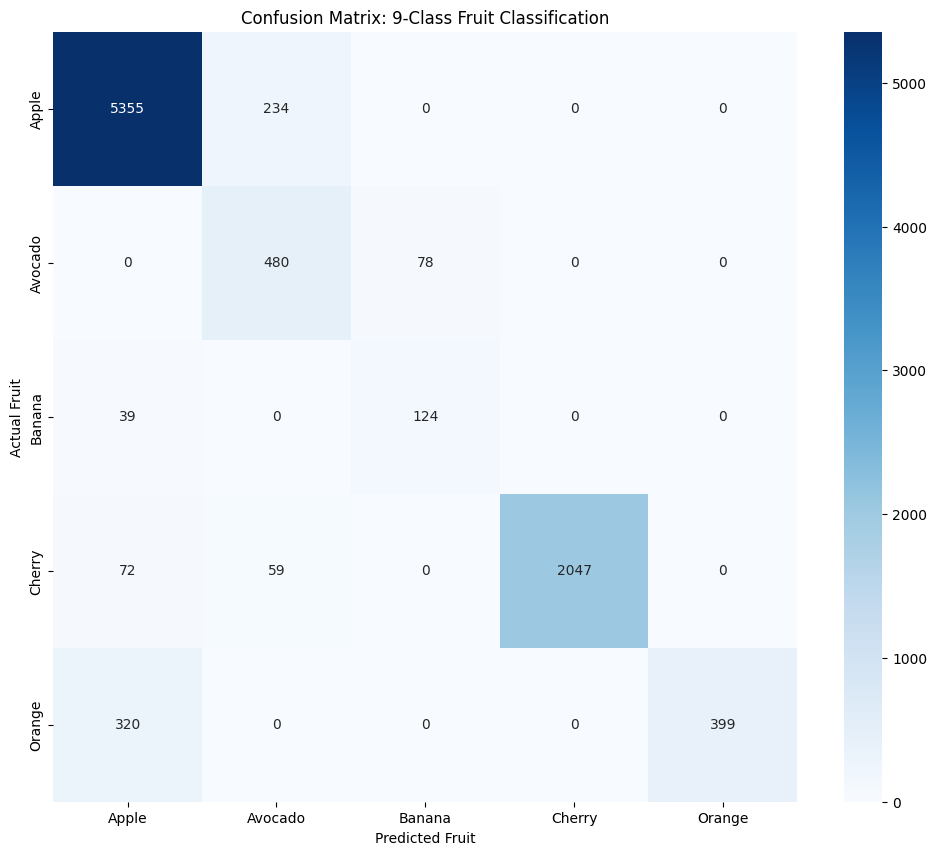


Classification Report:
              precision    recall  f1-score   support

       Apple       0.93      0.96      0.94      5589
     Avocado       0.62      0.86      0.72       558
      Banana       0.61      0.76      0.68       163
      Cherry       1.00      0.94      0.97      2178
      Orange       1.00      0.55      0.71       719

    accuracy                           0.91      9207
   macro avg       0.83      0.81      0.81      9207
weighted avg       0.92      0.91      0.91      9207


Project Analysis:
Overall Final Accuracy: 91.29%
Most frequent confusion: Actual Orange predicted as Apple (320 times)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("Evaluating model on validation data...")

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=new_class_names,
            yticklabels=new_class_names)
plt.title('Confusion Matrix: 9-Class Fruit Classification')
plt.ylabel('Actual Fruit')
plt.xlabel('Predicted Fruit')
plt.show()

# Print Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=new_class_names))

# Identify specific areas for your project report
print("\nProject Analysis:")
accuracy = np.sum(np.diag(cm)) / np.sum(cm)
print(f"Overall Final Accuracy: {accuracy:.2%}")

# Find the most confused pair
mask = np.eye(len(cm), dtype=bool)
cm_no_diag = np.where(mask, 0, cm)
max_confusion_idx = np.unravel_index(np.argmax(cm_no_diag), cm.shape)
print(f"Most frequent confusion: Actual {new_class_names[max_confusion_idx[0]]} "
      f"predicted as {new_class_names[max_confusion_idx[1]]} ({np.max(cm_no_diag)} times)")

Evaluating on your filtered test_ds...


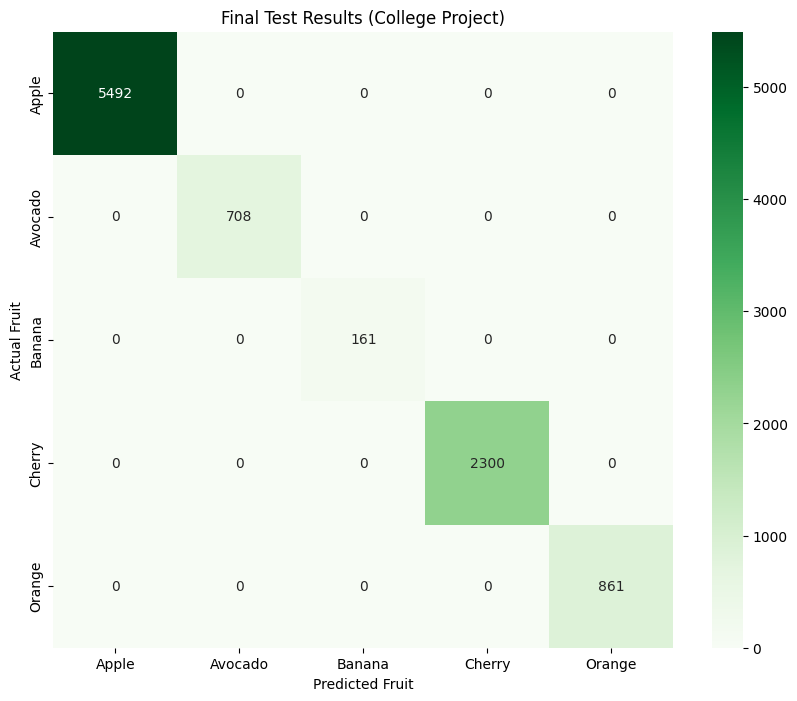


Classification Report:
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00      5492
     Avocado       1.00      1.00      1.00       708
      Banana       1.00      1.00      1.00       161
      Cherry       1.00      1.00      1.00      2300
      Orange       1.00      1.00      1.00       861

    accuracy                           1.00      9522
   macro avg       1.00      1.00      1.00      9522
weighted avg       1.00      1.00      1.00      9522



In [ ]:
print("Evaluating on your filtered test_ds...")

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 3. Generate and Plot Confusion Matrix
if len(y_true) > 0:
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=new_class_names,
                yticklabels=new_class_names)
    plt.title('Final Test Results (College Project)')
    plt.ylabel('Actual Fruit')
    plt.xlabel('Predicted Fruit')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=new_class_names))
else:
    print("Error: test_ds is empty. Please ensure you re-ran Cell 14.")

In [ ]:
from google.colab import files

files.download('fruit_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from keras import layers

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(64, 64, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model_mobilenet_lstm = keras.Sequential([
    layers.Input(shape=(64, 64, 3)),
    base_model,
    layers.Reshape((4, 1280)),
    layers.LSTM(128, return_sequences=False),
    layers.Dropout(0.5),
    layers.Dense(9, activation='softmax')
])

model_mobilenet_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_mobilenet = keras.callbacks.ModelCheckpoint(
    'mobilenet_lstm_best.keras',
    save_best_only=True,
    monitor='val_accuracy'
)

history_mobilenet = model_mobilenet_lstm.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    steps_per_epoch=300,
    callbacks=[early_stopping, reduce_lr, checkpoint_mobilenet]
)

/tmp/ipykernel_3086/3456399370.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.7401 - loss: 0.7335

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


300/300 ━━━━━━━━━━━━━━━━━━━━ 151s 468ms/step - accuracy: 0.8051 - loss: 0.5458 - val_accuracy: 0.8334 - val_loss: 0.5501 - learning_rate: 0.0010
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 132s 442ms/step - accuracy: 0.8780 - loss: 0.3401 - val_accuracy: 0.8362 - val_loss: 0.5582 - learning_rate: 0.0010
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 128s 429ms/step - accuracy: 0.8929 - loss: 0.2949 - val_accuracy: 0.8478 - val_loss: 0.5447 - learning_rate: 0.0010
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 127s 425ms/step - accuracy: 0.9109 - loss: 0.2486 - val_accuracy: 0.8622 - val_loss: 0.5687 - learning_rate: 0.0010
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 139s 464ms/step - accuracy: 0.9176 - loss: 0.2357 - val_accuracy: 0.8553 - val_loss: 0.5854 - learning_rate: 0.0010


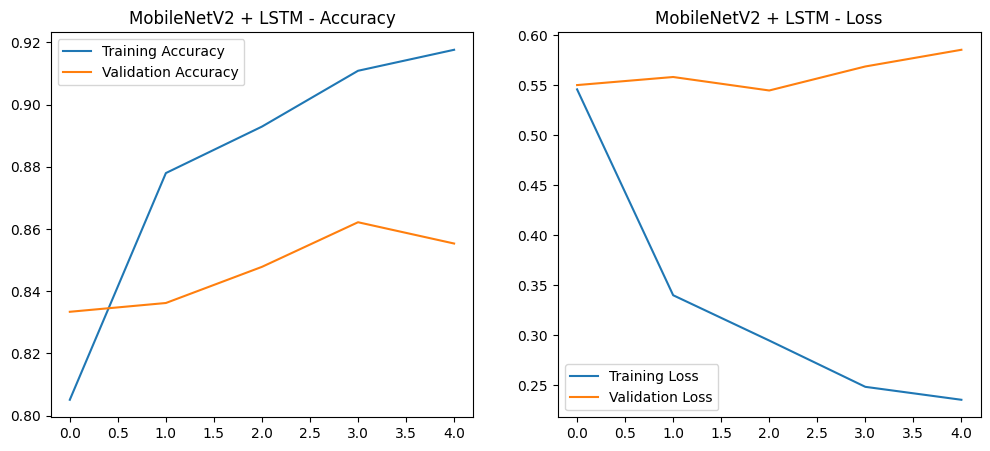

In [ ]:
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

# Run this after training
plot_history(history_mobilenet, "MobileNetV2 + LSTM")

In [ ]:
# Architecture 3: EfficientNetB0 + LSTM
base_efficientnet = tf.keras.applications.EfficientNetB0(
    input_shape=(64, 64, 3),
    include_top=False,
    weights='imagenet'
)
base_efficientnet.trainable = False

model_efficientnet_lstm = keras.Sequential([
    layers.Input(shape=(64, 64, 3)),
    # EfficientNet has its own internal rescaling, but for consistency:
    base_efficientnet,

    # EfficientNetB0 output is (None, 2, 2, 1280)
    layers.Reshape((4, 1280)),

    layers.LSTM(128, return_sequences=False),
    layers.Dropout(0.5),
    layers.Dense(9, activation='softmax')
])

model_efficientnet_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Checkpoint for EfficientNet
checkpoint_eff = keras.callbacks.ModelCheckpoint(
    'effnet_lstm_best.keras',
    save_best_only=True,
    monitor='val_accuracy'
)

# Train the third model
history_effnet = model_efficientnet_lstm.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    steps_per_epoch=300,
    callbacks=[early_stopping, reduce_lr, checkpoint_eff]
)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 195s 603ms/step - accuracy: 0.9465 - loss: 0.1487 - val_accuracy: 0.9007 - val_loss: 0.5891 - learning_rate: 0.0010
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 189s 631ms/step - accuracy: 0.9805 - loss: 0.0539 - val_accuracy: 0.9057 - val_loss: 0.5808 - learning_rate: 0.0010
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 167s 559ms/step - accuracy: 0.9954 - loss: 0.0144 - val_accuracy: 0.9121 - val_loss: 0.6361 - learning_rate: 2.0000e-04
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 165s 551ms/step - accuracy: 0.9966 - loss: 0.0105 - val_accuracy: 0.9107 - val_loss: 0.6766 - learning_rate: 2.0000e-04
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 180s 601ms/step - accuracy: 0.9980 - loss: 0.0087 - val_accuracy: 0.9090 - val_loss: 0.7068 - learning_rate: 4.0000e-05


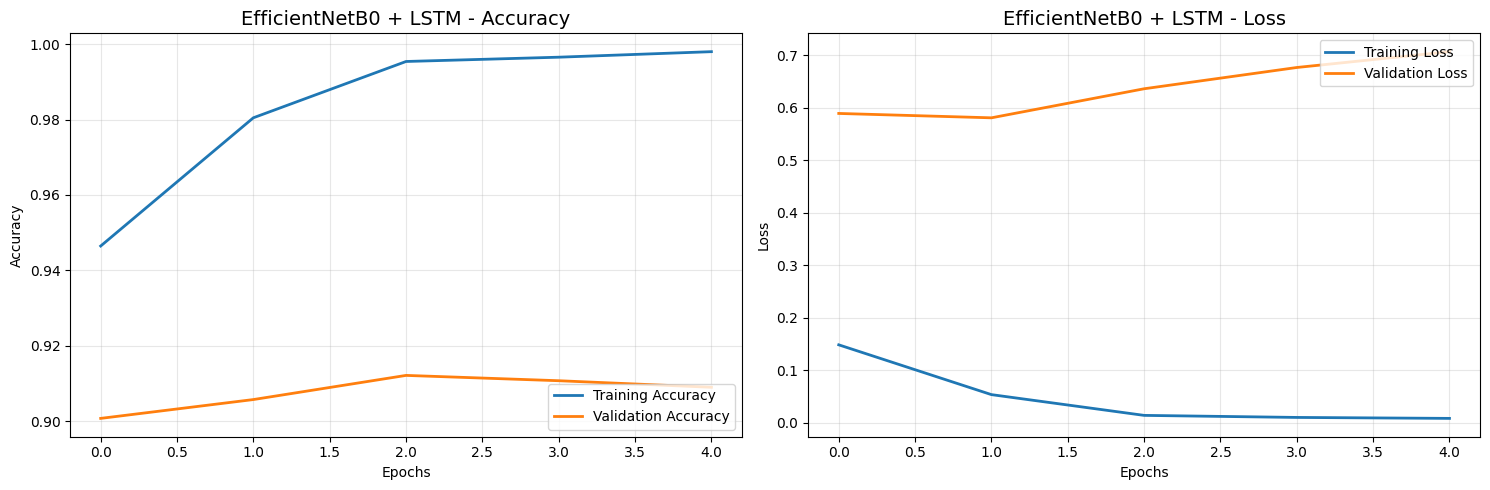

In [ ]:
# 1. Define the plotting function (included here so the block is self-contained)
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(15, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
    plt.title(f'{title} - Accuracy', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
    plt.title(f'{title} - Loss', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 2. Call the function for your 3rd model
# Note: Ensure you have finished running the .fit() for history_effnet before this
plot_history(history_effnet, "EfficientNetB0 + LSTM")

Evaluating EfficientNetB0 + LSTM on the Test Set...


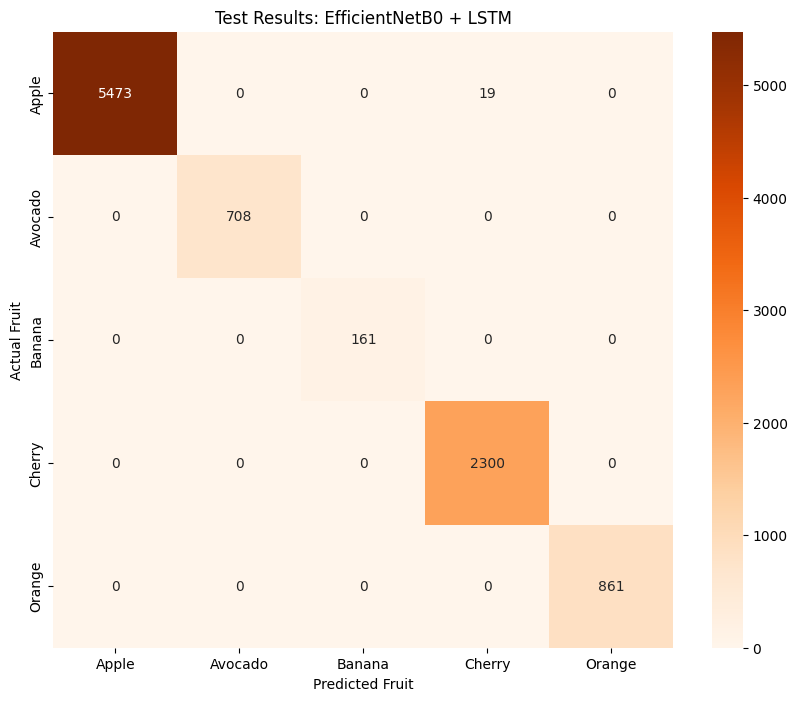


FINAL TEST CLASSIFICATION REPORT (Model 3):
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00      5492
     Avocado       1.00      1.00      1.00       708
      Banana       1.00      1.00      1.00       161
      Cherry       0.99      1.00      1.00      2300
      Orange       1.00      1.00      1.00       861

    accuracy                           1.00      9522
   macro avg       1.00      1.00      1.00      9522
weighted avg       1.00      1.00      1.00      9522



In [ ]:
import numpy as np
import seaborn as sns

# 1. Load the best version of the third model
# Ensure the filename matches what was used in your training cell
model_eff = tf.keras.models.load_model('effnet_lstm_best.keras')

print("Evaluating EfficientNetB0 + LSTM on the Test Set...")

# 2. Use the test_ds (ensure it was loaded with 64x64 resolution)
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model_eff.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 3. Generate and Plot the Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', # Different color for distinction
            xticklabels=new_class_names,
            yticklabels=new_class_names)
plt.title('Test Results: EfficientNetB0 + LSTM')
plt.ylabel('Actual Fruit')
plt.xlabel('Predicted Fruit')
plt.show()

# 4. Final Classification Report
print("\nFINAL TEST CLASSIFICATION REPORT (Model 3):")
print(classification_report(y_true, y_pred, target_names=new_class_names))